# JEM - Coupling Quick Start

This notebook demonstrates a JAX-ESM (JEM) example using JAX-GCM (JCM) and Slab Ocean Model as an aquaplanet.

In [1]:
from pathlib import Path

import jcm
from jcm.geometry import Geometry
import jax_datetime as jdt

from jem.components import JCM, SlabOceanModel
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

/home/tienyiao/miniconda3/envs/jaxesm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurations

In [2]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
output_dir = Path("output/JCM_SOM").resolve()
output_dir.mkdir(exist_ok=True, parents=True)
one_second = jdt.to_timedelta(1, "second")

## Creating Flux and Scalar Exchange between Components

In [3]:
mapper = BasicMapper()
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("ocn", "forcing.total_heat_flux"),
    regridder = lambda x: x,  # identity is default
)
mapper.add_mapping(
    source = ("ocn", "state.sea_surface_temperature"),
    target = ("atm", "forcing.sea_surface_temperature"),
)

## Create Components

In [4]:
atm_model = jcm.model.Model(
    start_date=start_datetime,
)

atm_model = JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
    land_model_active = False,
)

model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Notice: No mask_file given. Set fmask = 0.
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Model info: 
/Model
├── ● component_info <dict>
│   ├── ● atm <dict>
│   │   └── ○ diffusion <str>: DiffusionFilter(vor_q_timescale=43200, vor_q_order=2, temp_timescale=86400, temp_order=2, div_timescale=7200, div_order=1)
│   └── ● ocn <dict>
│       └── ○ relaxation_time

## Run Coupled Model

In [18]:
simulation_interval = jdt.to_timedelta(100, "day")
initial_state, final_state, predictions = model.run(
    workflow=["mapper", "atm", "ocn"],
    iterations = int(simulation_interval / coupling_timestep),
)

/home/tienyiao/miniconda3/envs/jaxesm/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Boundary does not exist. Idealized initial SST will be used.
grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.
Flattened workflow:  mapper, atm, ocn
Doing: ocn.state.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> ocn.forcing.total_heat_flux
Using method: None


Simulation: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:41<00:00,  1.61s/it]


## Output into NetCDF

In [19]:
output_dict = model.predictions_to_xarray(predictions)
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print("Output file: ", str(output_file))
    ds.to_netcdf(output_file, engine="netcdf4")

Output file:  /home/tienyiao/projects/project_jem/repos_jem/jax-esm/notebooks/output/JCM_SOM/atm.nc
Output file:  /home/tienyiao/projects/project_jem/repos_jem/jax-esm/notebooks/output/JCM_SOM/ocn.nc


## Visualization

In [7]:
import matplotlib.pyplot as plt

### Atmosphere

In [8]:
ds = output_dict["atm"]
print(str(ds))

<xarray.Dataset> Size: 37MB
Dimensions:                          (time: 10, level: 8, lon: 96, lat: 48)
Coordinates:
  * lon                              (lon) float64 768B 0.0 3.75 ... 352.5 356.2
  * lat                              (lat) float64 384B -87.16 -83.48 ... 87.16
  * level                            (level) float32 32B 0.95 0.835 ... 0.025
  * time                             (time) datetime64[ns] 80B 2000-01-01 ......
Data variables: (12/79)
    condensation.dqlsc               (time, level, lon, lat) float32 1MB ...
    mod_radcon.tau2.2                (time, level, lon, lat) float32 1MB ...
    surface_flux.u0                  (time, lon, lat) float32 184kB ...
    shortwave_rad.stratz             (time, lon, lat) float32 184kB ...
    humidity.rh                      (time, level, lon, lat) float32 1MB ...
    surface_flux.evap.1              (time, lon, lat) float32 184kB ...
    ...                               ...
    shortwave_rad.fsol               (time, lon, l

#### Precipitation

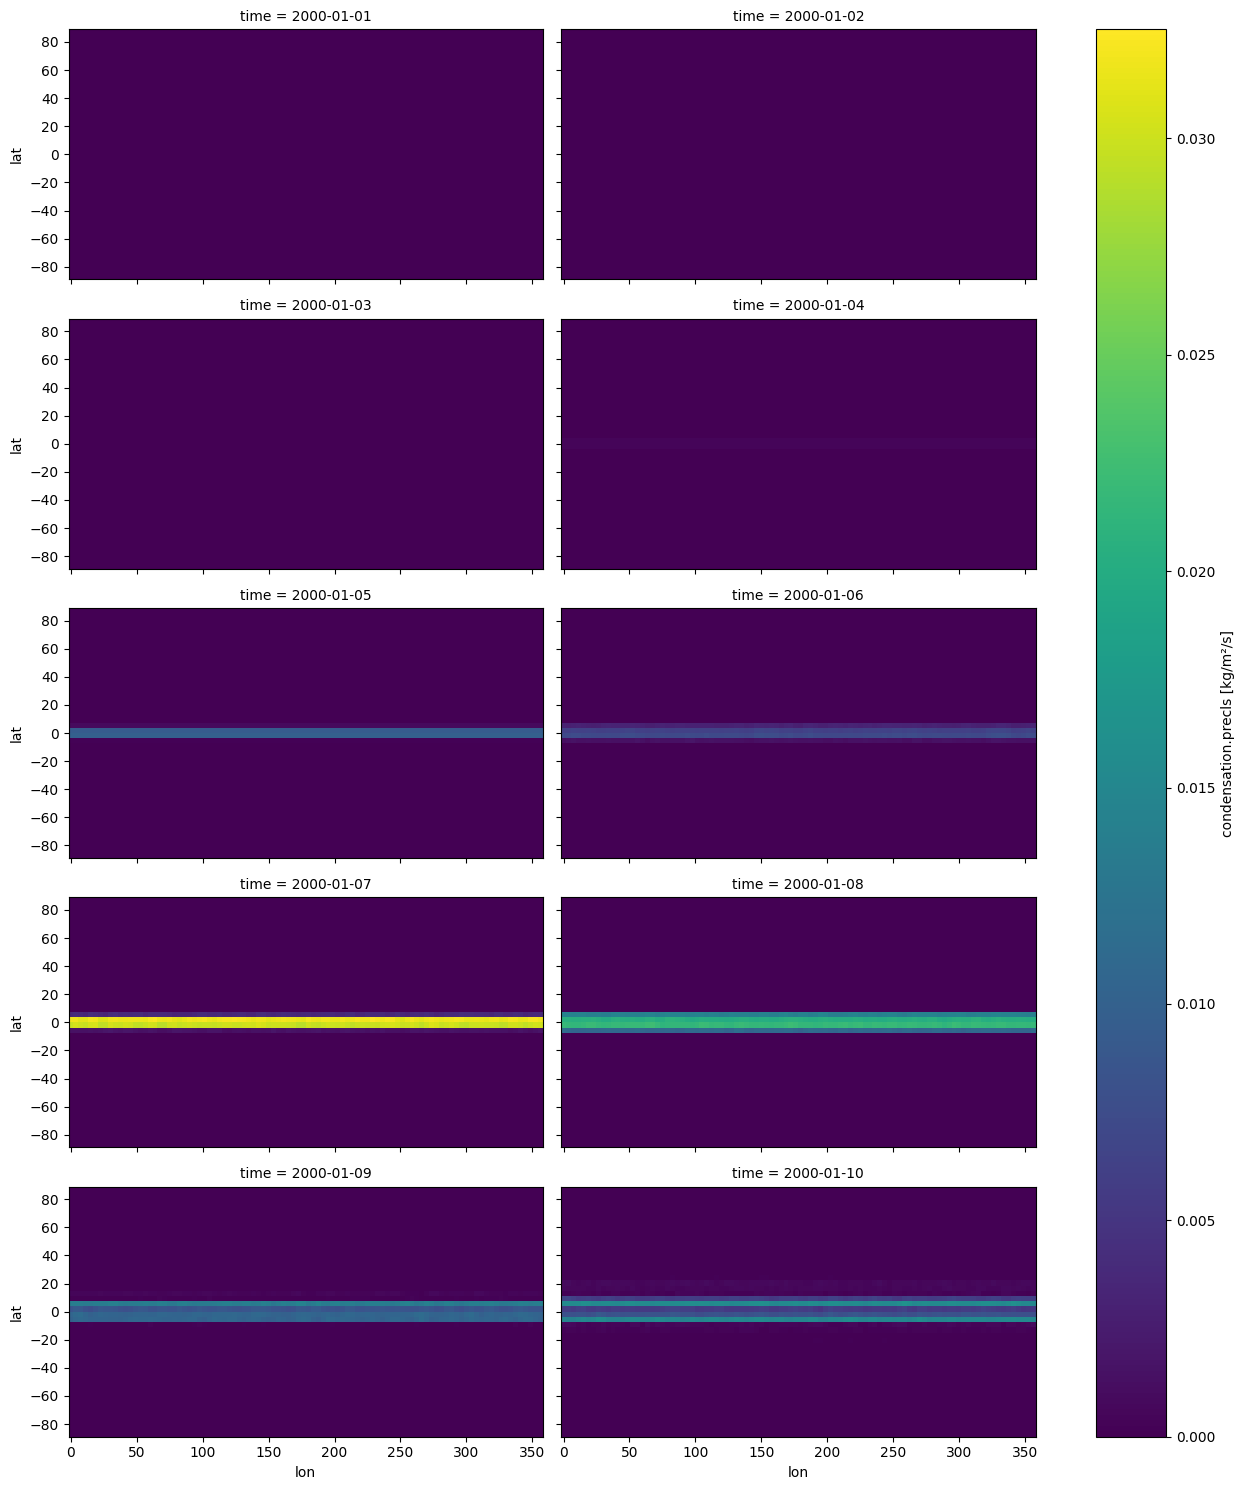

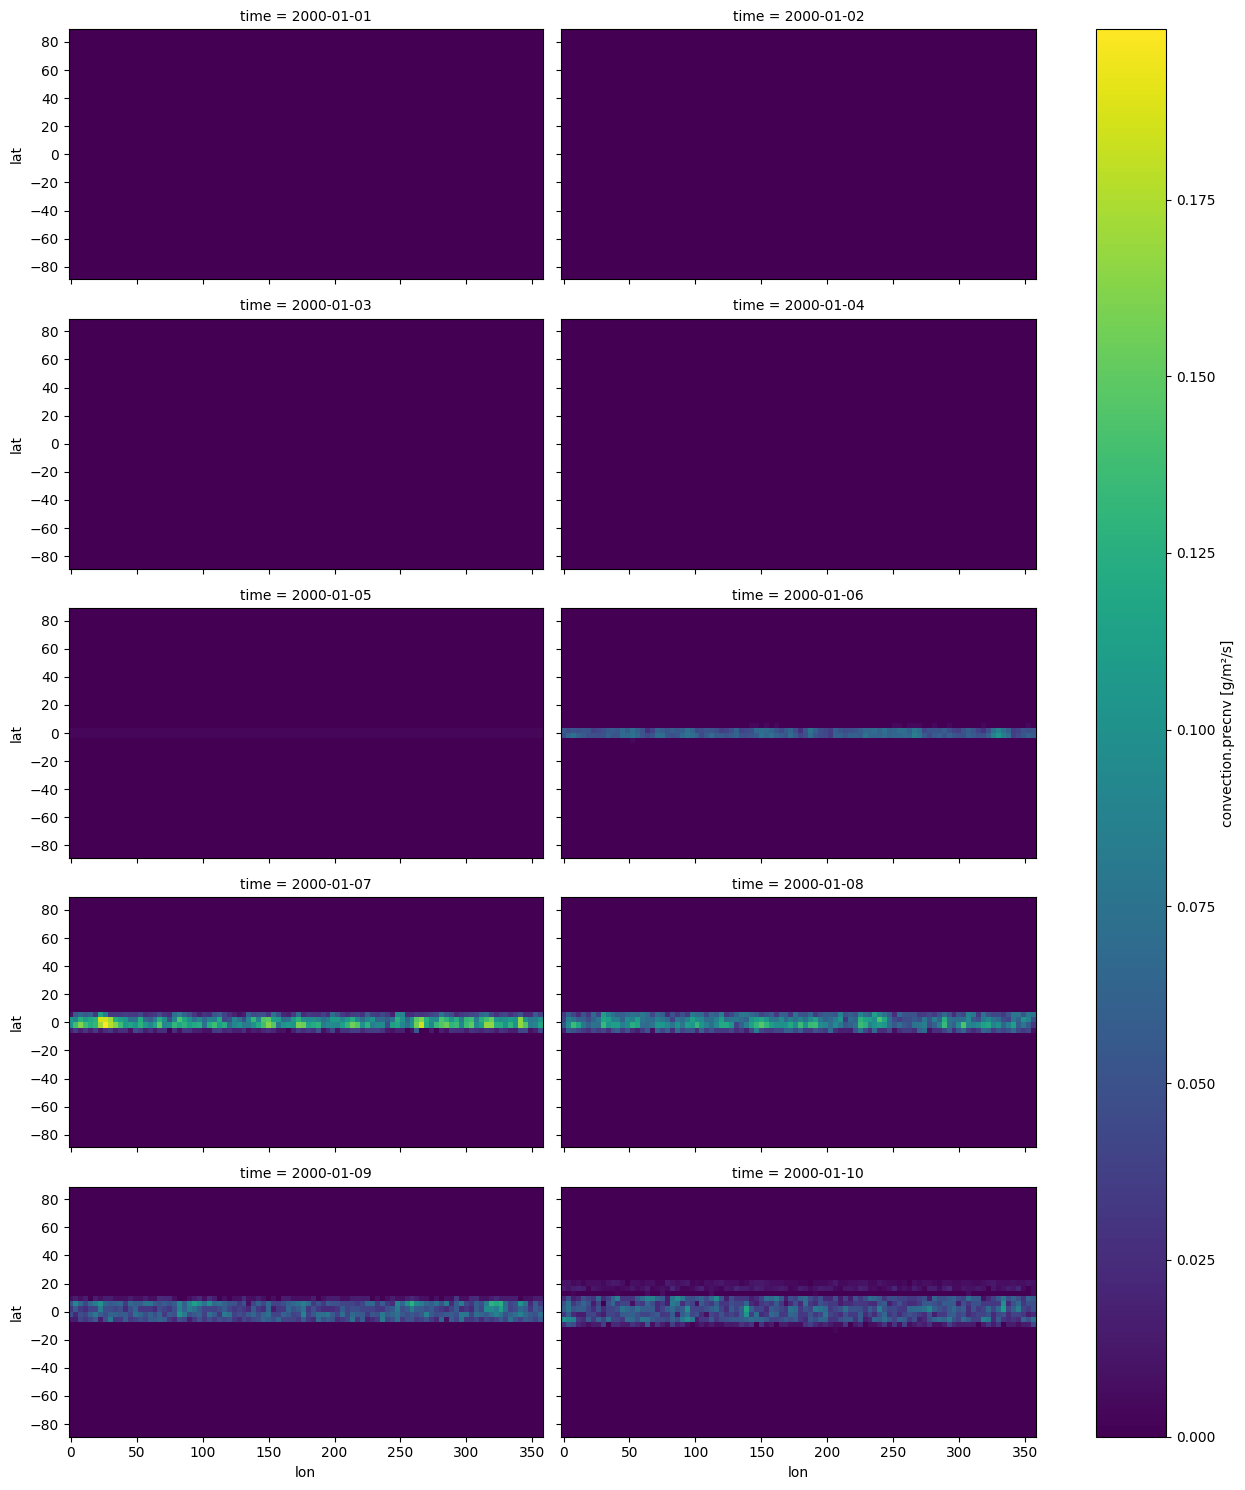

In [9]:
ds['condensation.precls'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)
ds['convection.precnv'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)

#### Moisture

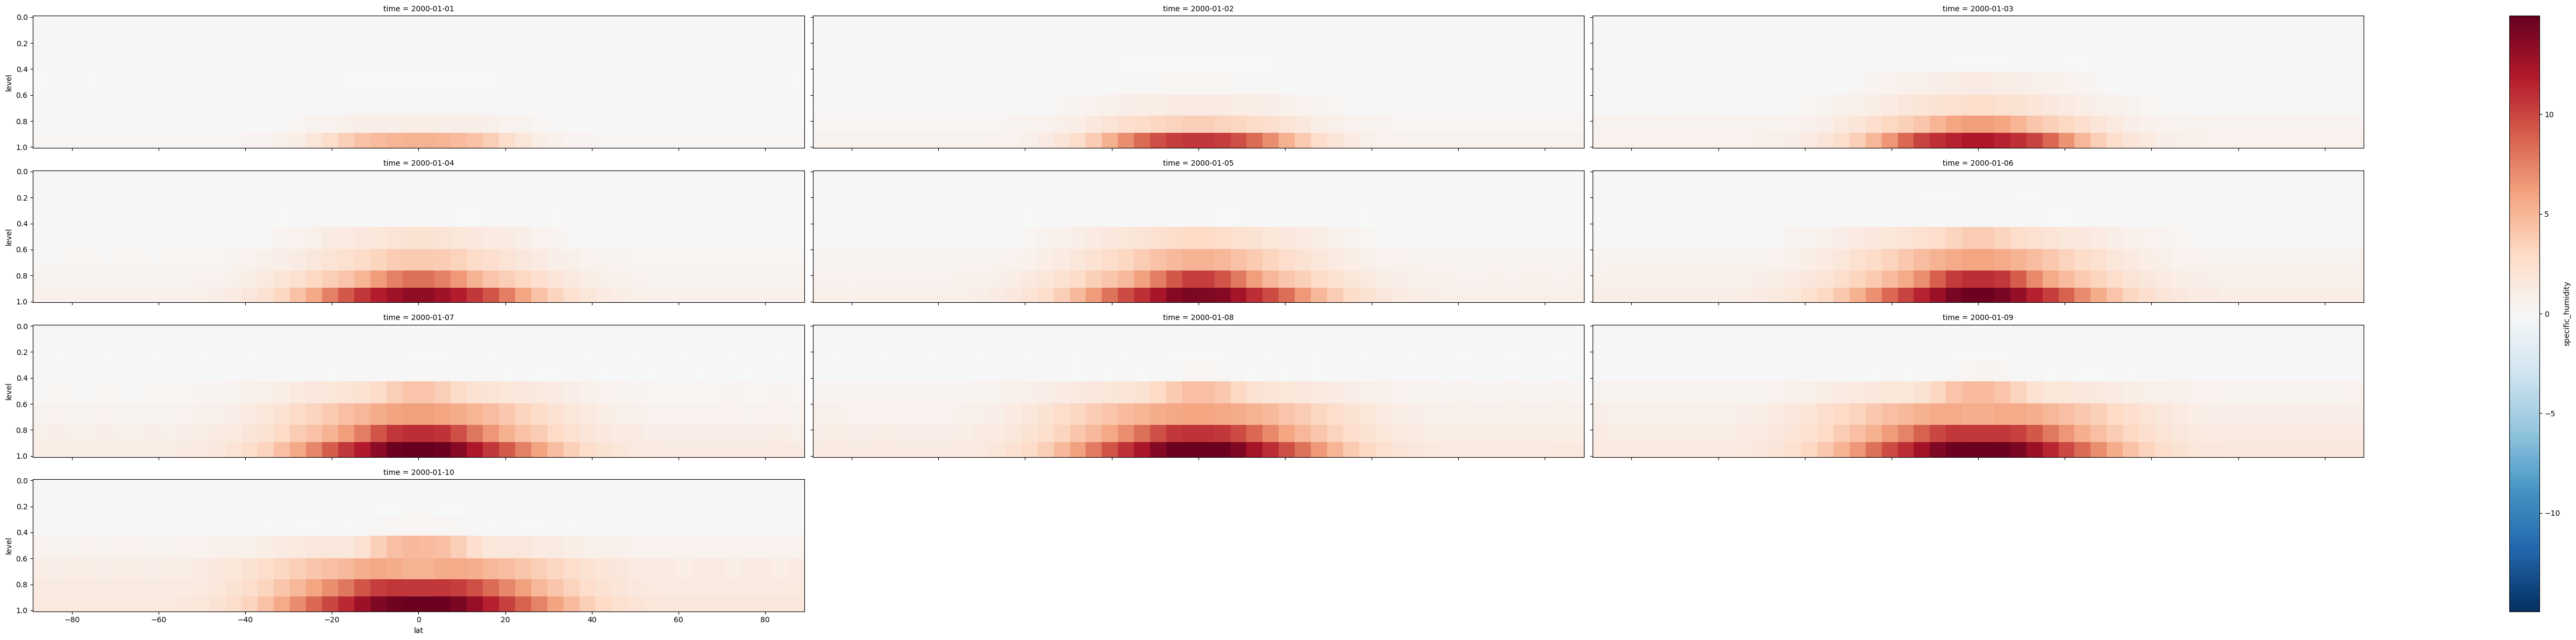

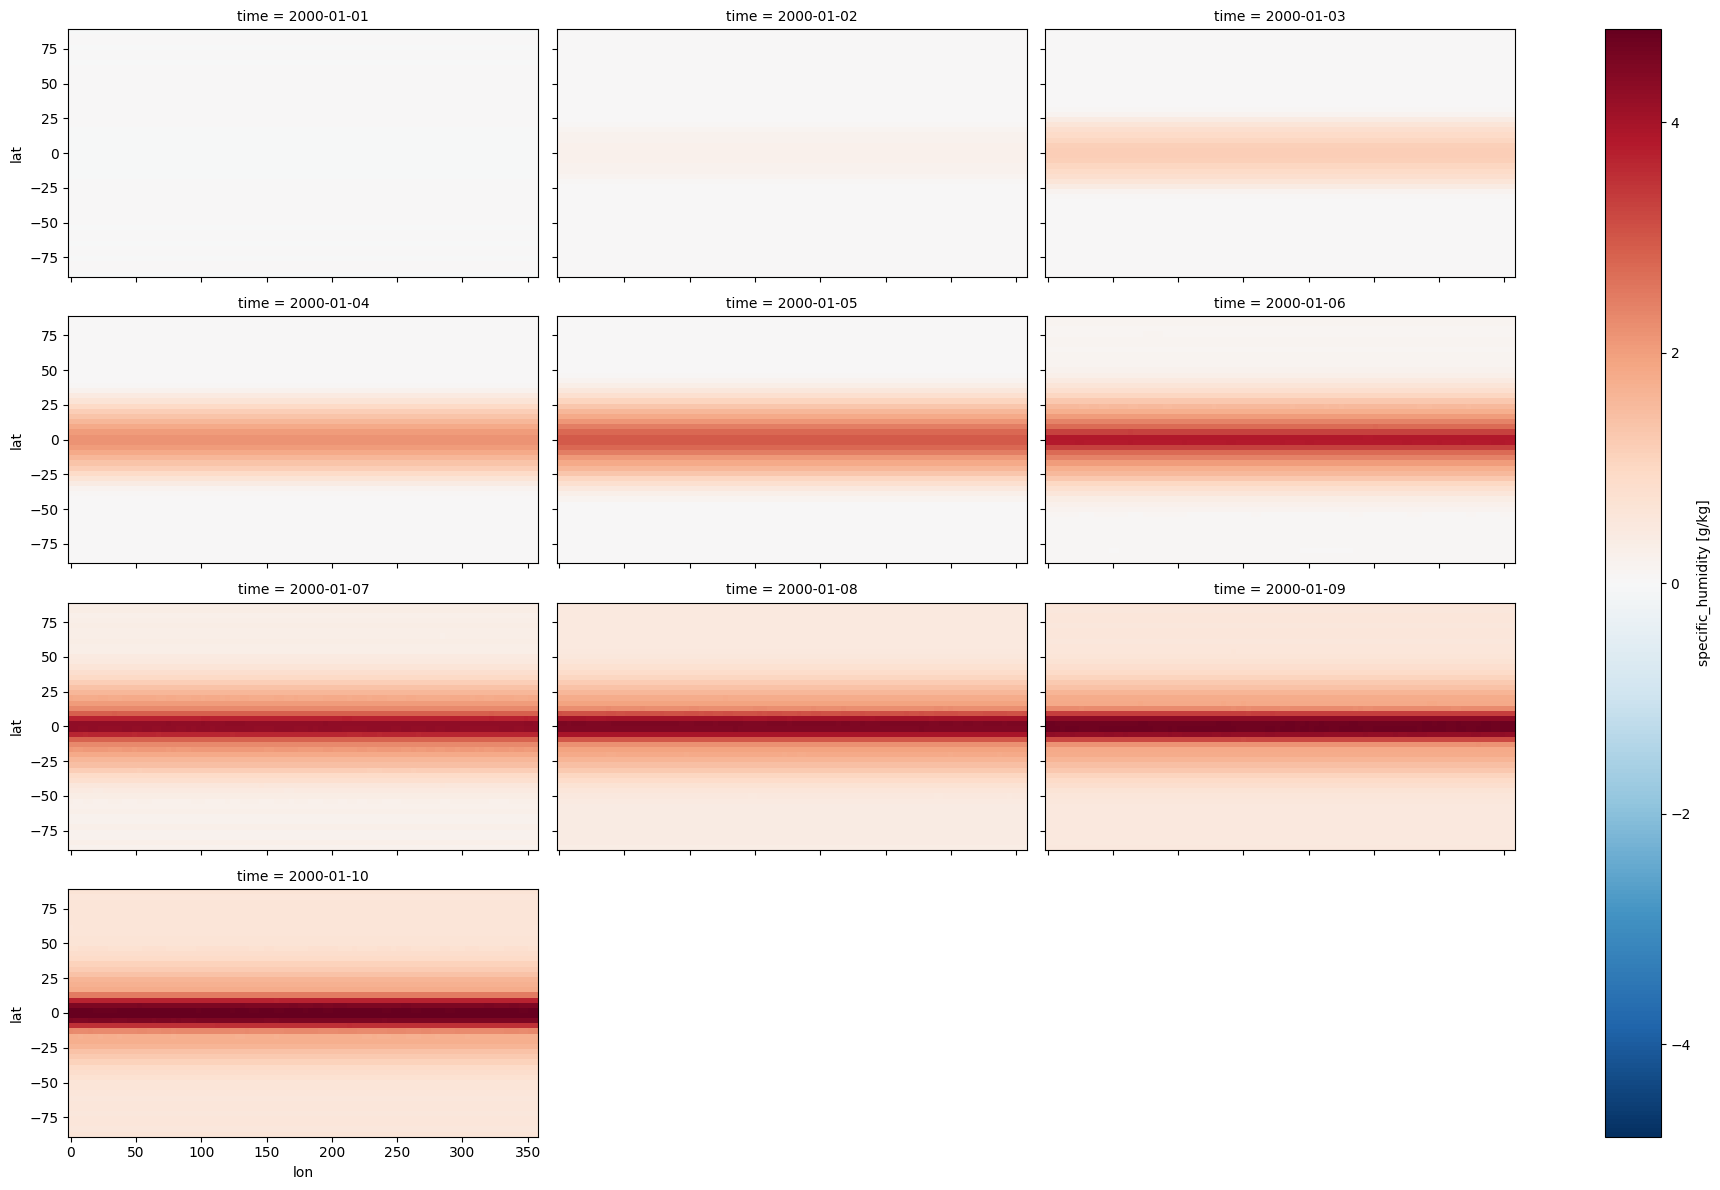

In [10]:
ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

#### Clouds

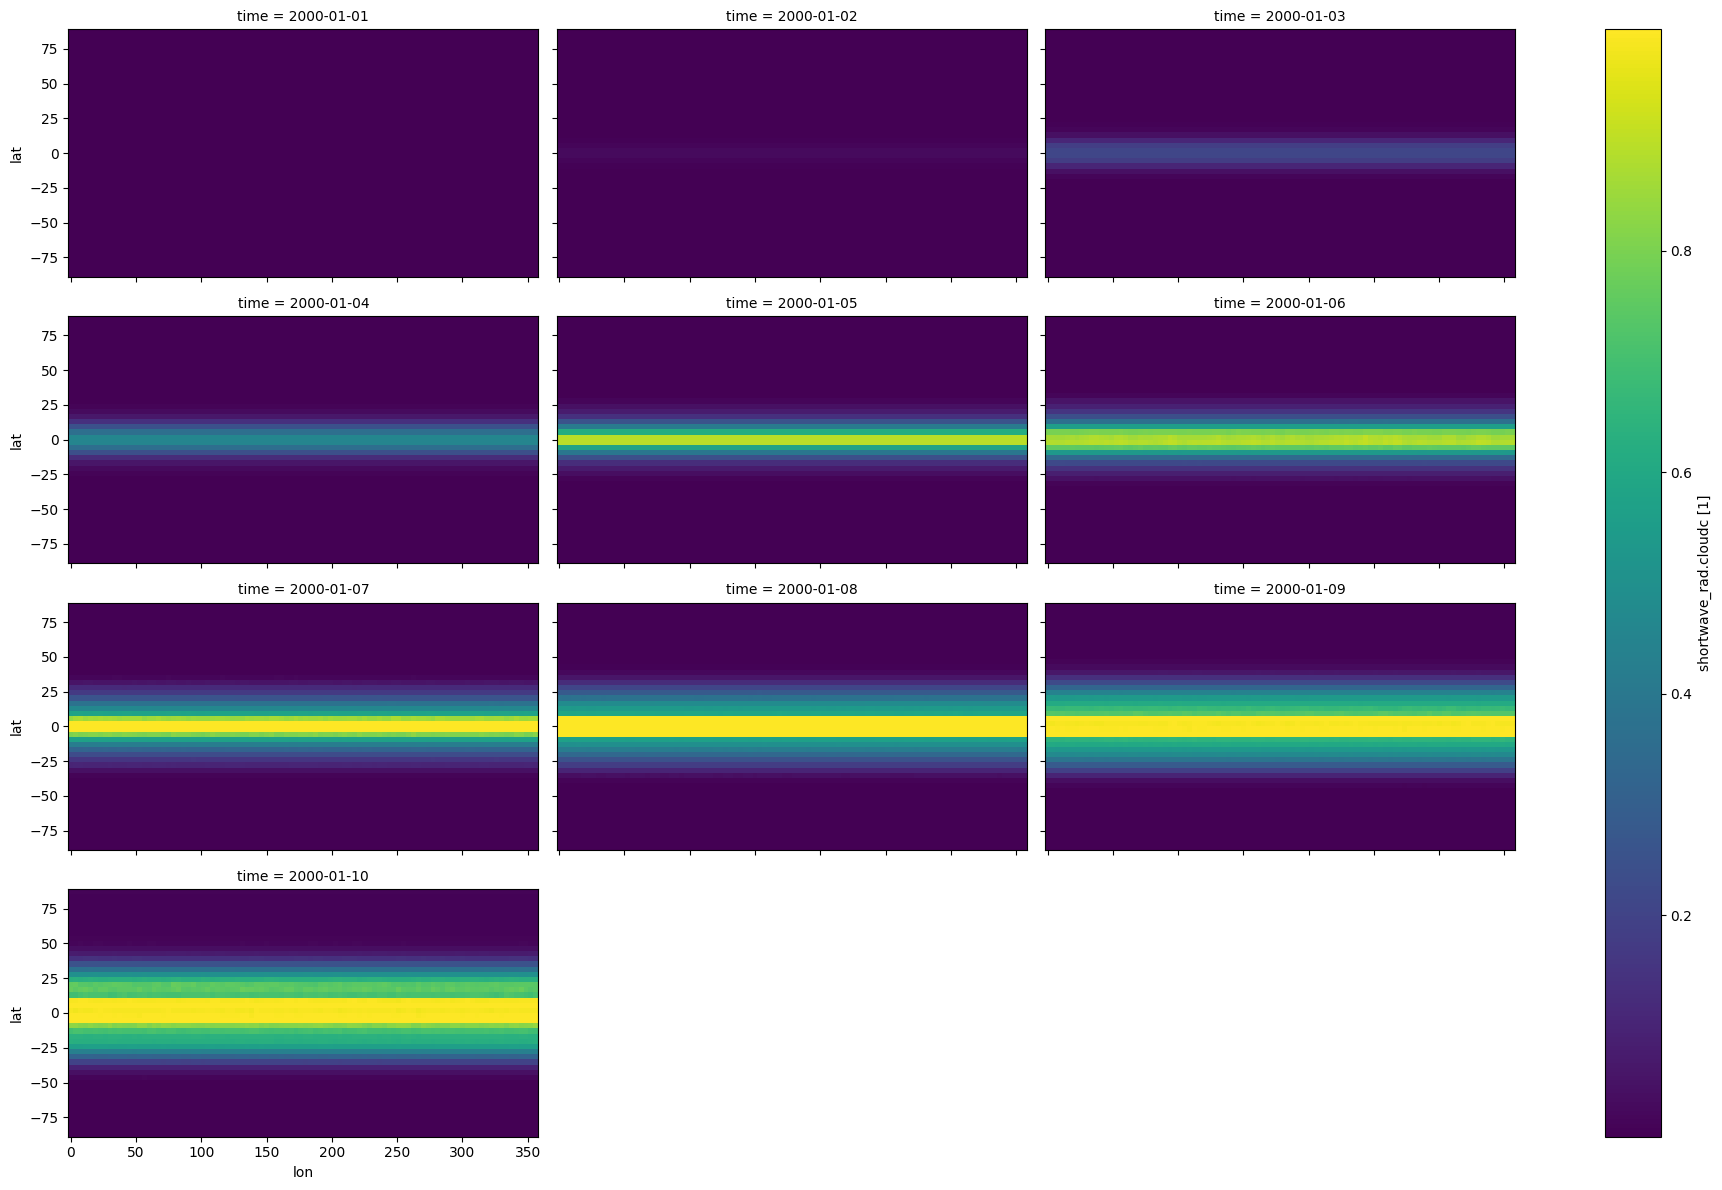

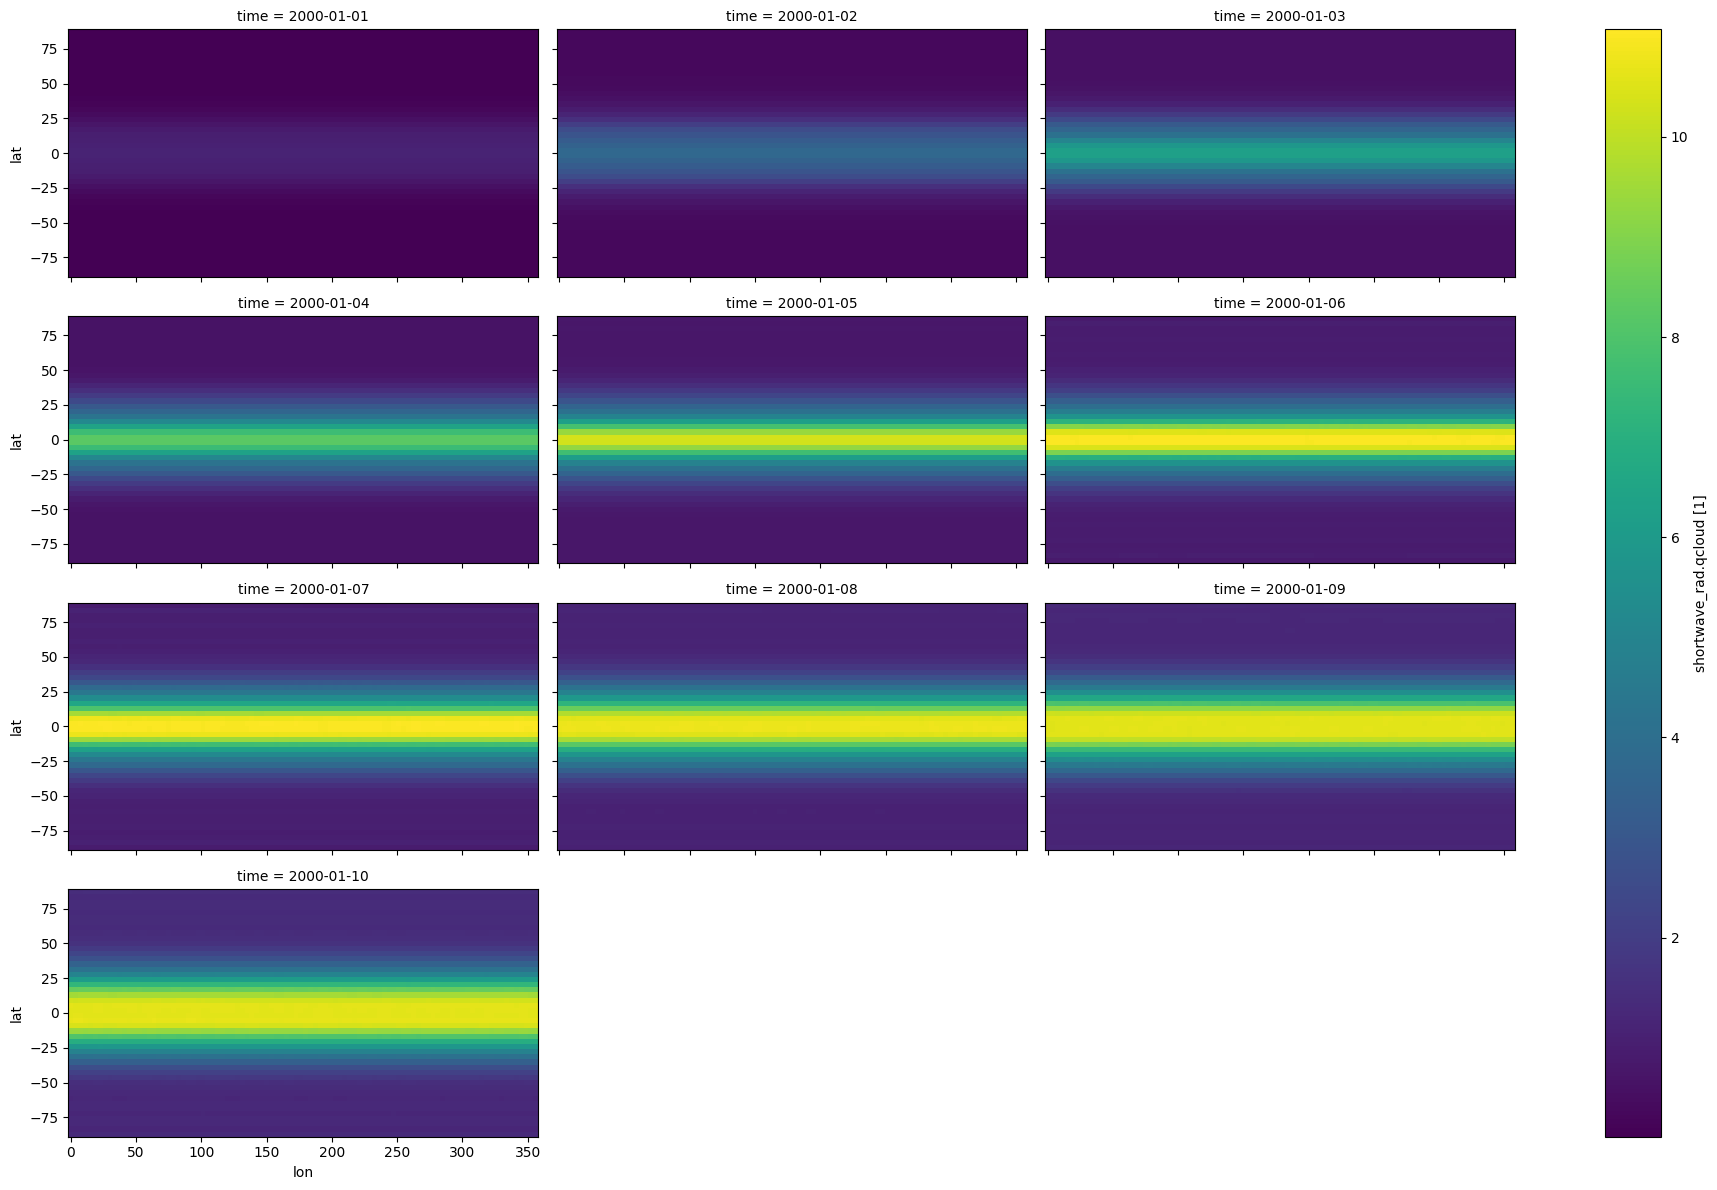

In [11]:
ds['shortwave_rad.cloudc'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
ds['shortwave_rad.qcloud'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

### Ocean

In [12]:
ds = output_dict["ocn"]
print(str(ds))

<xarray.Dataset> Size: 590kB
Dimensions:                  (time: 10, longitude: 96, latitude: 48)
Coordinates:
  * time                     (time) float32 40B 24.0 48.0 72.0 ... 216.0 240.0
    latitude2D               (longitude, latitude) float32 18kB ...
    longitude2D              (longitude, latitude) float32 18kB ...
Dimensions without coordinates: longitude, latitude
Data variables:
    sea_surface_temperature  (time, longitude, latitude) float32 184kB ...
    mixed_layer_depth        (time, longitude, latitude) float32 184kB ...
    total_heat_flux          (time, longitude, latitude) float32 184kB ...


#### Sea Surface Temperature
We plot both the SST and its difference with respect to the initial condition.

Text(0.5, 0.98, 'Sea Surface Temperature [${}^\\circ \\mathrm{C}$]')

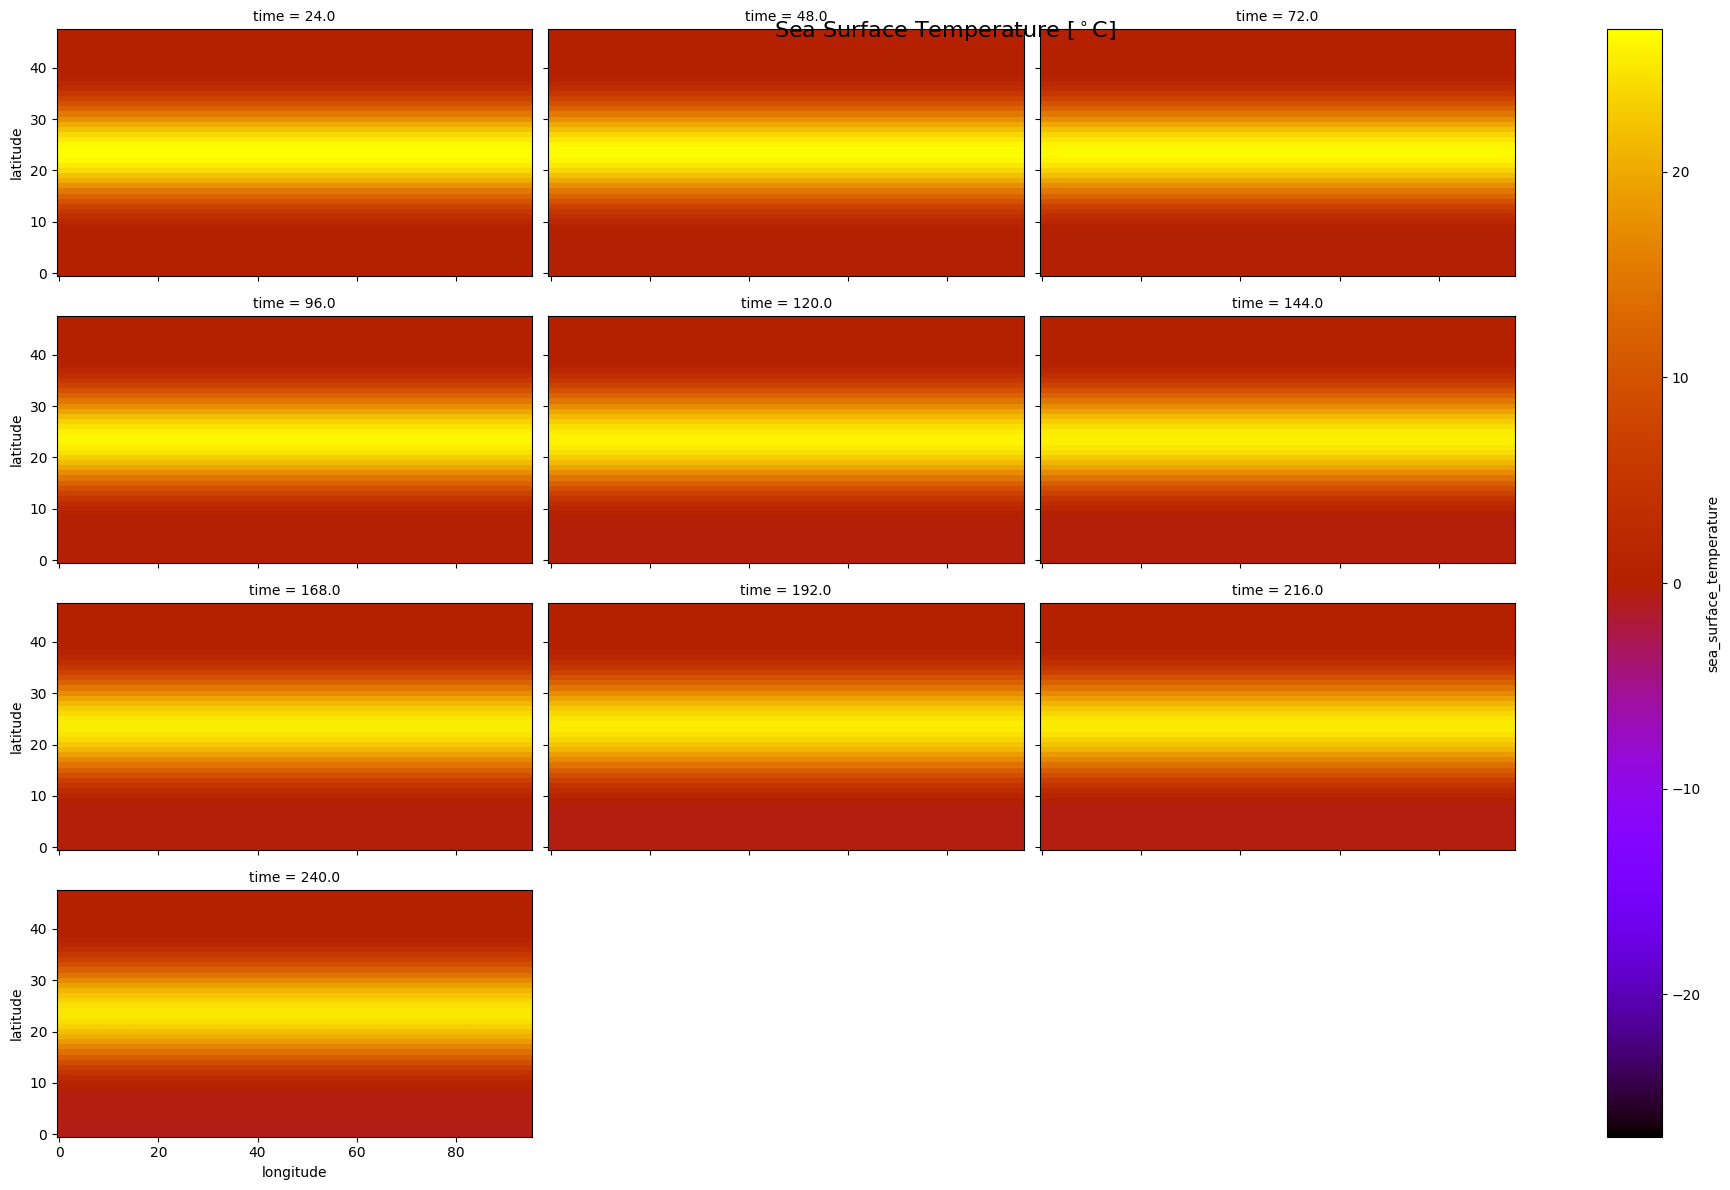

In [13]:
g = (ds['sea_surface_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="gnuplot")
g.fig.suptitle("Sea Surface Temperature [${}^\\circ \\mathrm{C}$]", fontsize=16)

Text(0.5, 0.98, 'Difference of Sea Surface Temperature between labeled time and initial condition [${}^\\circ \\mathrm{C}$]')

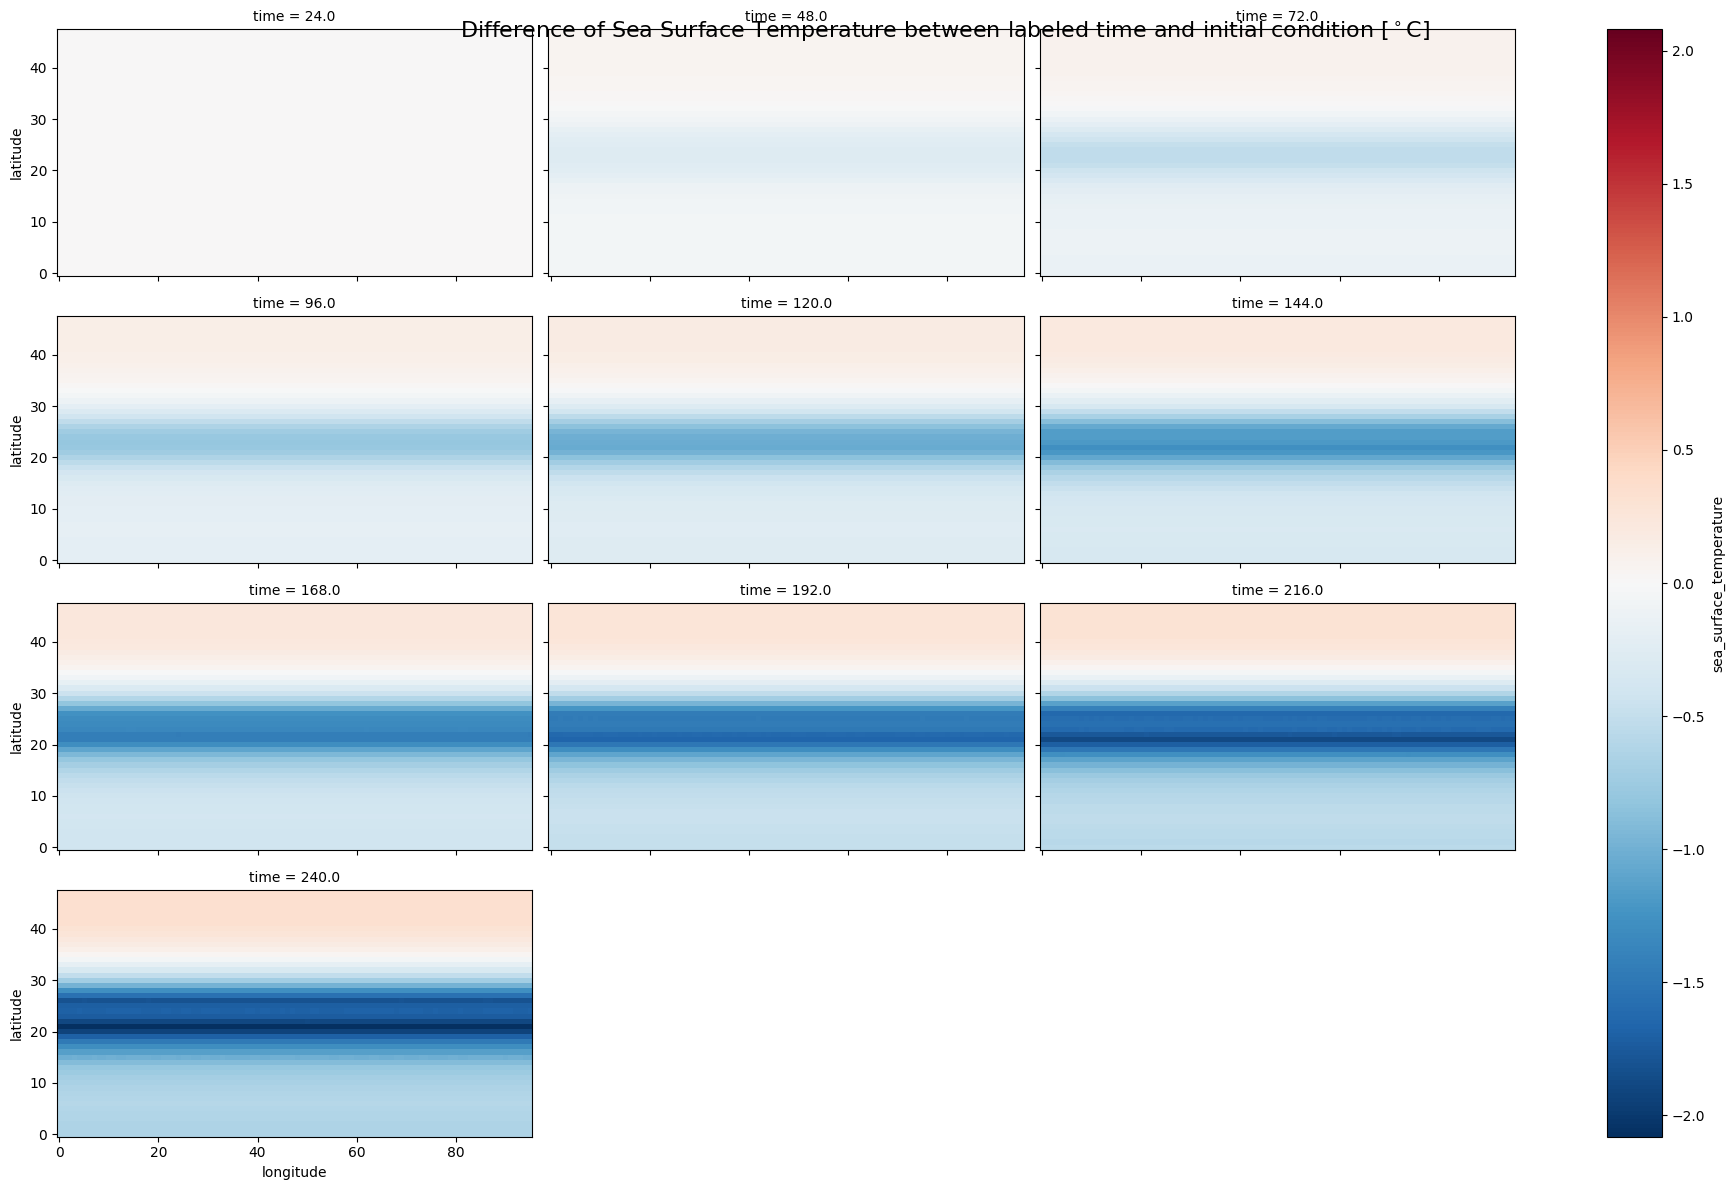

In [14]:
g = (ds['sea_surface_temperature'] - ds['sea_surface_temperature'].isel(time=0)).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, center=0)
g.fig.suptitle("Difference of Sea Surface Temperature between labeled time and initial condition [${}^\\circ \\mathrm{C}$]", fontsize=16)

#### Total heat flux

Text(0.5, 0.98, 'Total heat flux (upward positive) [$\\mathrm{W} / \\mathrm{m}^2$]')

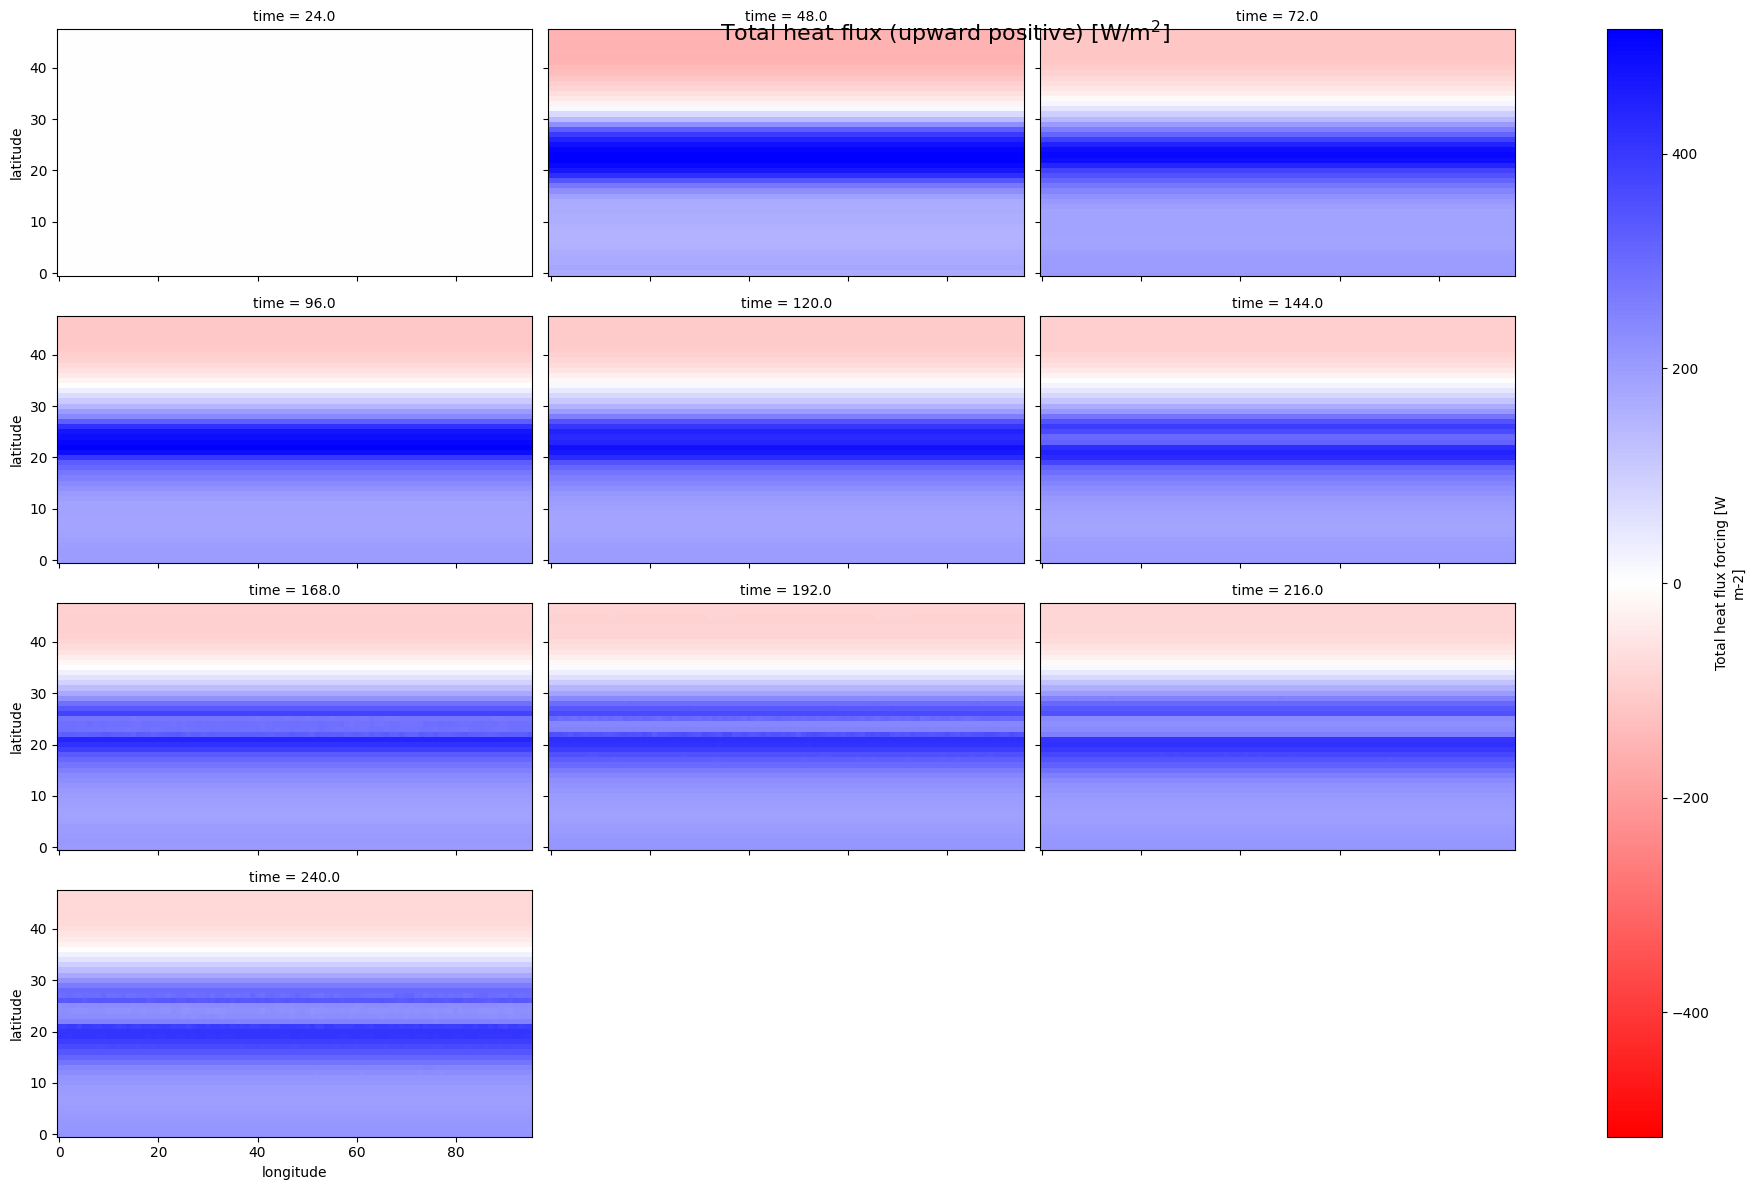

In [15]:
g = ds['total_heat_flux'].plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="bwr_r", center=0.0)
g.fig.suptitle("Total heat flux (upward positive) [$\\mathrm{W} / \\mathrm{m}^2$]", fontsize=16)

In [16]:
plt.show()

## Making animation of specific humidity of the surface grid

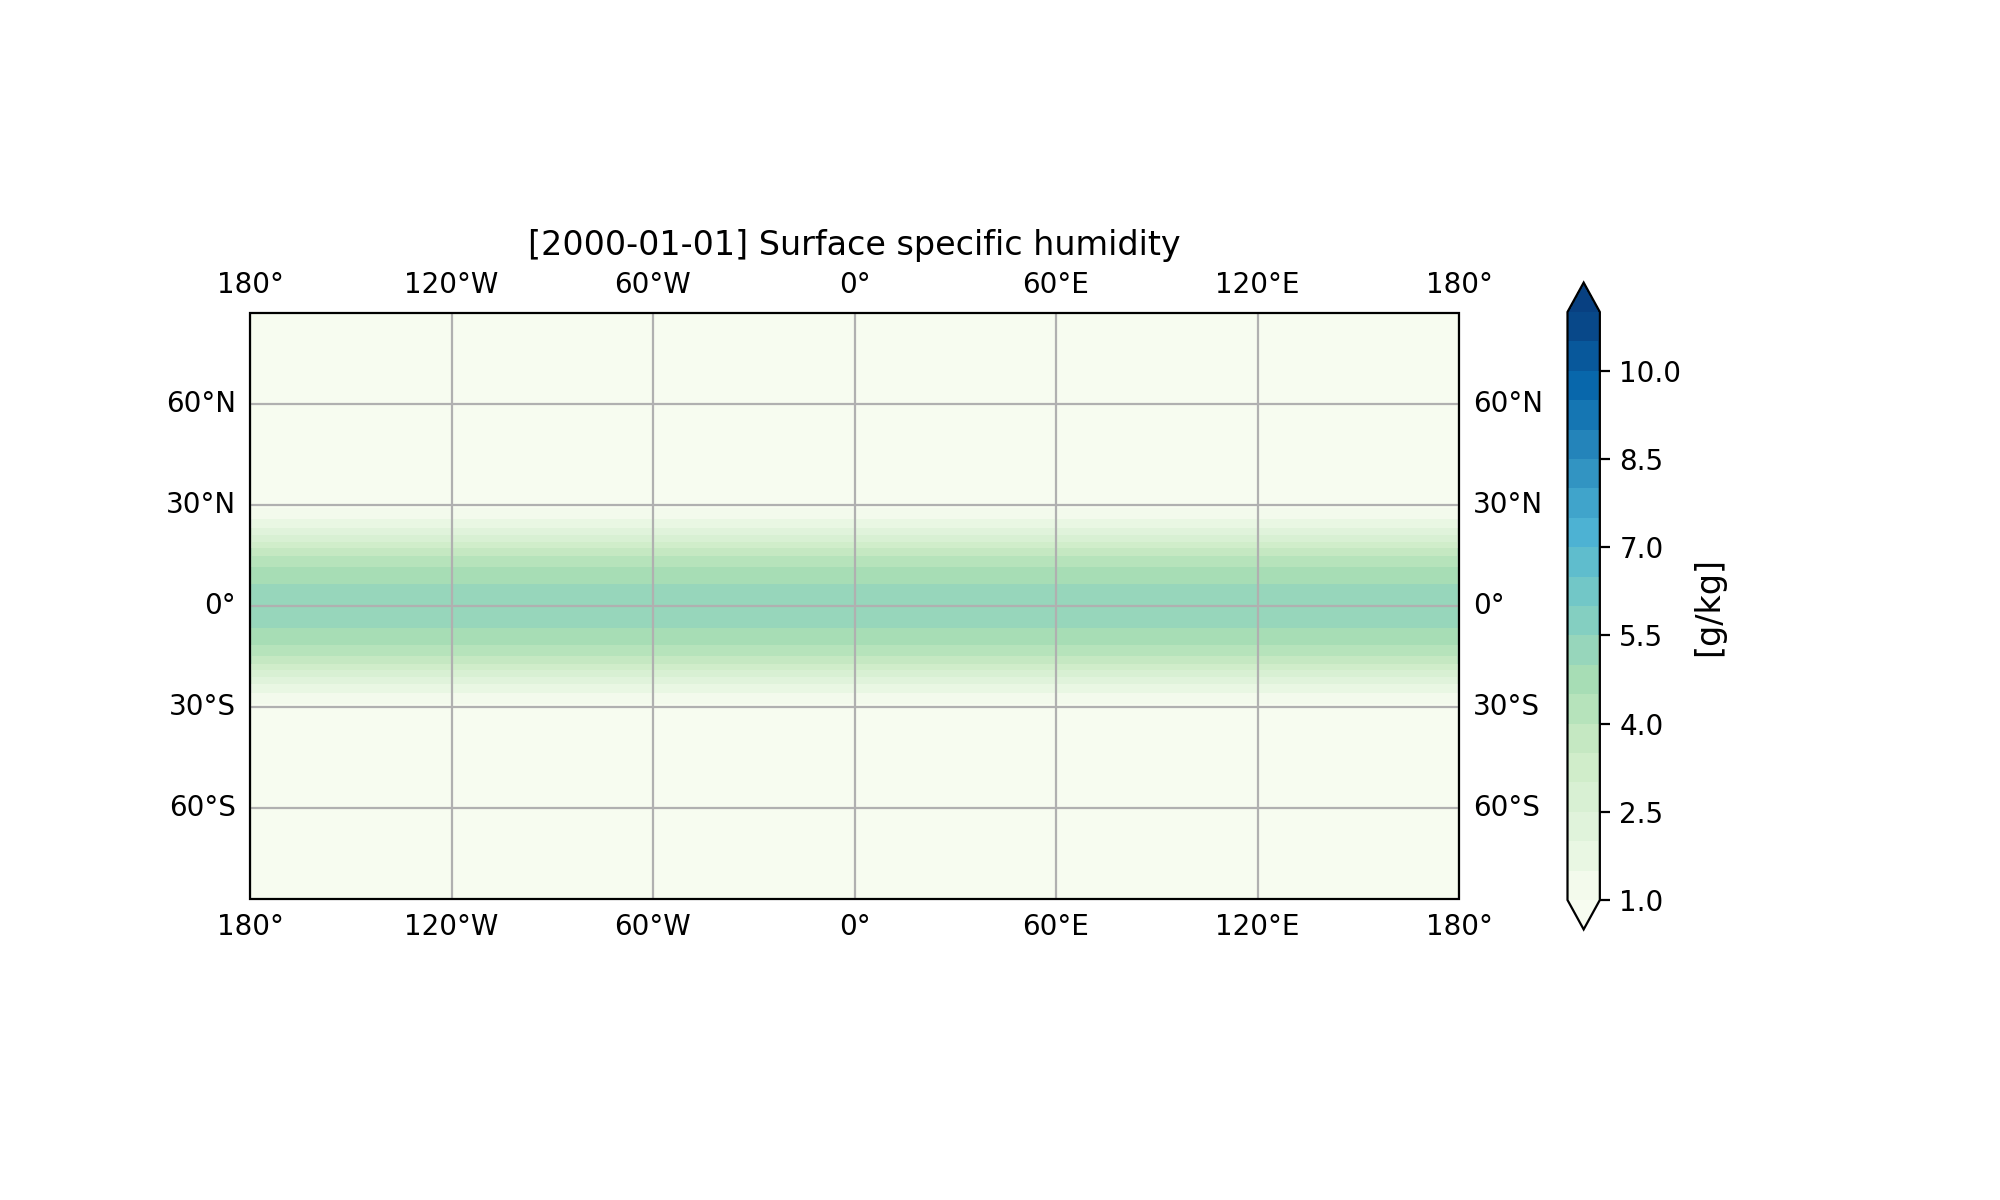

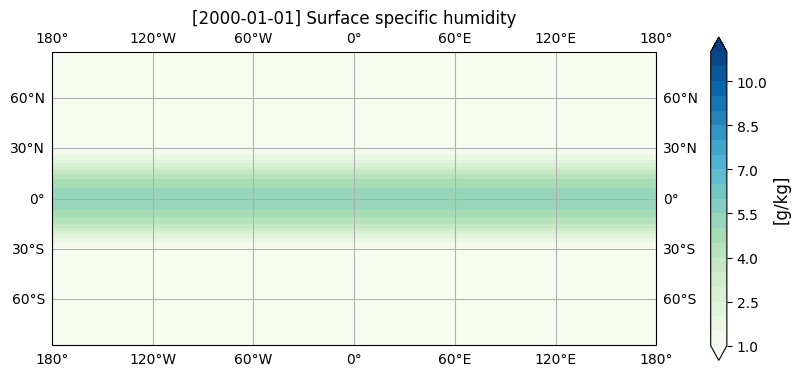

In [21]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import numpy as np

data = output_dict["atm"]["specific_humidity"]

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)
cb = None
cf = None

def update(frame):
    global cf, cb   
    _data = data.isel(time=frame, level=0)
 
    if cf is not None:
        for coll in cf.collections:
            coll.remove()
   
    # Plot the humidity field for the current time step
    lat = _data.coords["lat"]
    lon = _data.coords["lon"]
    cyclic_data, cyclic_lon = add_cyclic_point(_data.to_numpy().transpose(), coord=lon)
    mappable = ax.contourf(
        cyclic_lon, lat,
        cyclic_data,
        levels=1 + np.linspace(0, 1, 21) * 10,
        transform=ccrs.PlateCarree(), 
        cmap='GnBu',
        extend="both",
    )
    
    ax.set_title(f"[{_data['time'].dt.strftime('%Y-%m-%d').to_numpy().item()}] Surface specific humidity")
    if cb is None:
        cb = plt.colorbar(ax=ax, mappable=mappable, orientation='vertical', shrink=0.7, pad=0.07)
        cb.set_label("[g/kg]", fontsize=12)
    
    return [cf,]
    
# Generate and save
ani = FuncAnimation(fig, update, frames=len(data.coords["time"]), interval=120, blit=False)
ani.save('humidity_map.gif', writer='pillow', dpi=200)
display(Image('humidity_map.gif'))